# Phase 4: Benchmarking Missing-Modality Imputation

This notebook compares MIMIR’s missing-modality imputation performance against baseline methods:
- **TOBMI***: kNN-style donor-based translation using a shared embedding space (baseline implementation)
- **MOFA+**: global latent factor model trained on the training set and used to impute missing modalities on test scenarios

All methods are evaluated on the same leave-one-modality-out test scenarios produced in Phase 3.
Performance is measured using MSE, Pearson r, and Spearman ρ, computed on flattened sample × feature matrices.


In [2]:
import src.others.tobmi as tobmi
import src.others.mofa_imputer as mofa

from src.data_utils import *
from src.mae_masked import *
from src.shared_finetune import *
from src.impute import *
from src.translation import *
from src.evaluation import *

In [3]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Subset
import numpy as np
import random
from typing import Dict, List, Tuple
import pickle
from torch.optim import Adam
import matplotlib.pyplot as plt
import pandas as pd
import json

In [4]:
with open('tcga_redo_mlomicZ.pkl', 'rb') as f:
    multi_omic_data = pickle.load(f)
    
print(multi_omic_data.keys())

common_samples, train_idx, val_idx, test_idx = load_shared_splits_from_json(
    multi_omic_data,
    json_path='splits.json'
)
print(f"Shared N={len(common_samples)} | train={len(train_idx)} | val={len(val_idx)}| test={len(test_idx)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'mps' if torch.backends.mps.is_available() else 'cpu')

dict_keys(['cnv', 'miRNA', 'rna', 'methylation'])
Shared N=8034 | train=6409 | val=798| test=800


## TOBMI* baseline (donor-based translation)

We evaluate a TOBMI-style baseline that imputes missing modalities using donor samples from the training set.
The method is applied to each leave-one-out scenario generated in Phase 3.

Key settings:
- donors: `train_samples`
- distance metric: cosine
- k: default (`sqrt(n_donor)` when `k=None`)
- scaling: disabled (`scale=False`) since inputs are already z-scored


In [5]:
multi_ds = MultiOmicDataset({m: df for m, df in multi_omic_data.items()})
test_samples = [multi_ds.common_samples[i] for i in test_idx]
train_samples = [multi_ds.common_samples[i] for i in train_idx]

tobmi_preds = tobmi.translate_from_scenario_dir(
    scenarios_dir="scenarios_leave_one_out_test",
    multi_omic_data=multi_omic_data,
    train_samples=train_samples,
    k=None,          # None defaults to sqrt(n_donor)
    metric="cosine",
    scale=False,     # already scaled
    save_pred_pickle_path = 'tobmi_leave_one_out_test.pkl'
)

[Saved predictions] tobmi_leave_one_out_test.pkl


In [6]:
metrics_tobmi = evaluate_imputations(tobmi_preds, multi_omic_data, plot_scatter=False)

In [7]:
metrics_tobmi

{(('cnv', 'methylation', 'miRNA'), 'rna'): {'mse': 0.47733214578929867,
  'pearson': 0.7239877468537868,
  'spearman': 0.7044006430261418,
  'n_points': 2405600},
 (('cnv', 'methylation', 'rna'), 'miRNA'): {'mse': 0.47502184080648013,
  'pearson': 0.7232670140800352,
  'spearman': 0.689964490679471,
  'n_points': 306400},
 (('cnv', 'miRNA', 'rna'), 'methylation'): {'mse': 0.5154825945946258,
  'pearson': 0.6988779493384366,
  'spearman': 0.6914524658582142,
  'n_points': 2508098},
 (('methylation', 'miRNA', 'rna'), 'cnv'): {'mse': 0.7330537149012469,
  'pearson': 0.5108500023432762,
  'spearman': 0.49755773227112166,
  'n_points': 2484000}}

## Feature-wise wins (per-gene / per-feature correlation)

Beyond global metrics, we compute feature-wise Pearson correlation between predicted and true values.
For each target modality, we report the fraction of features where MIMIR achieves higher correlation than the baseline.
This highlights whether performance gains are broad-based or driven by a small subset of features.

In [8]:
compare_tobmi = compare_methods_per_feature(
    method1 ="imputations_leave_one_out_test.pkl",
    method2 ="tobmi_leave_one_out_test.pkl",
    multi_omic_data=multi_omic_data,
    plot_scatter=False,
    m1_name= "MIMR",
    m2_name = "TOBMI"
)

In [9]:
compare_tobmi[(('cnv', 'methylation', 'miRNA'),
  'rna')]

{'corr_MIMR': A1BG      0.797454
 A1CF      0.878540
 A2ML1     0.781886
 AADAC     0.801602
 ABAT      0.835842
             ...   
 ZNF667    0.817196
 ZNF676    0.707778
 ZNF750    0.853206
 ZNHIT2    0.505900
 ZYG11A    0.782042
 Length: 3007, dtype: float64,
 'corr_TOBMI': A1BG      0.756593
 A1CF      0.831435
 A2ML1     0.761755
 AADAC     0.752364
 ABAT      0.819000
             ...   
 ZNF667    0.736004
 ZNF676    0.618599
 ZNF750    0.816150
 ZNHIT2    0.465695
 ZYG11A    0.731546
 Length: 3007, dtype: float64,
 'n_features': 3007,
 'n_better_MIMR': 0.9926837379447955}

## MOFA+ baseline (global factor model)

We train a **single global MOFA+ model** on the training split only.
This model learns a shared latent factor space across modalities and is then used to impute missing modalities in each test scenario.

This setup is intended to be a fair “train once, reuse for all scenarios” baseline (as opposed to fitting a model per scenario).


In [ ]:
# 1. Train global MOFA on train_samples only
mofa_hdf5 = "mofa_global_train.hdf5"
mofa.train_global_mofa(
    multi_omic_data=multi_omic_data,
    train_samples=train_samples,
    out_hdf5_path=mofa_hdf5,
    # keep n_factors/train_iter=None to use MOFA defaults
    n_factors=256,
    train_iter=None,
    seed=1,          # optional
    verbose=True,
)

In [12]:
mofa_hdf5 = "mofa_global_train.hdf5"
# 2. Use the global model to impute all scenarios
mofa_preds = mofa.translate_from_scenario_dir(
    scenarios_dir="scenarios_leave_one_out_test",
    mofa_hdf5_path=mofa_hdf5,
    multi_omic_data=multi_omic_data,
    # projection_view=None -> pick first present modality per scenario
    projection_view=None,
    use_multi_view_projection=True,   # flip to True later if you want multi-view LS
    verbose=True,
    save_pred_pickle_path="mofa_leave_one_out_test_global.pkl",
)


[MOFA translate] Scenario file: scenario_present_cnv_methylation_miRNA_missing_rna.pkl
[MOFA impute] present=['cnv', 'miRNA', 'methylation'], target=rna, n_scenario=800

[MOFA translate] Scenario file: scenario_present_cnv_methylation_rna_missing_miRNA.pkl
[MOFA impute] present=['cnv', 'rna', 'methylation'], target=miRNA, n_scenario=800

[MOFA translate] Scenario file: scenario_present_cnv_miRNA_rna_missing_methylation.pkl
[MOFA impute] present=['cnv', 'miRNA', 'rna'], target=methylation, n_scenario=800

[MOFA translate] Scenario file: scenario_present_methylation_miRNA_rna_missing_cnv.pkl
[MOFA impute] present=['miRNA', 'rna', 'methylation'], target=cnv, n_scenario=800
[MOFA translate] Saved predictions to mofa_leave_one_out_test_global.pkl


We impute each leave-one-out scenario using the trained global MOFA+ model.
By default, the scenario-to-latent projection uses `projection_view=None` (first available modality),
with an option to use multi-view least squares projection (`use_multi_view_projection=True`).
We set `n_factors=256` to match MIMIR’s shared embedding dimension for a roughly comparable capacity.



In [13]:
mofa_metrics = evaluate_imputations(mofa_preds, multi_omic_data, plot_scatter=False)

In [14]:
mofa_metrics

{(('cnv', 'methylation', 'miRNA'), 'rna'): {'mse': 0.4785552421975921,
  'pearson': 0.731605739195057,
  'spearman': 0.7193784365463822,
  'n_points': 2405600},
 (('cnv', 'methylation', 'rna'), 'miRNA'): {'mse': 0.5433732763455935,
  'pearson': 0.7006777267165583,
  'spearman': 0.6710404266455333,
  'n_points': 306400},
 (('cnv', 'miRNA', 'rna'), 'methylation'): {'mse': 0.4668819110599075,
  'pearson': 0.7400025831677043,
  'spearman': 0.740072897064761,
  'n_points': 2508098},
 (('methylation', 'miRNA', 'rna'), 'cnv'): {'mse': 1.435702712145543,
  'pearson': 0.5123254481526208,
  'spearman': 0.4417283771908501,
  'n_points': 2484000}}

In [15]:
compare_mofa = compare_methods_per_feature(
    method1 ="imputations_leave_one_out_test.pkl",
    method2 ="mofa_leave_one_out_test_global.pkl",
    multi_omic_data=multi_omic_data,
    plot_scatter=False,
    m1_name= "MIMR",
    m2_name = "MOFA"
)

In [16]:
compare_mofa[(('cnv', 'methylation', 'miRNA'),
  'rna')]

{'corr_MIMR': A1BG      0.797454
 A1CF      0.878540
 A2ML1     0.781886
 AADAC     0.801602
 ABAT      0.835842
             ...   
 ZNF667    0.817196
 ZNF676    0.707778
 ZNF750    0.853206
 ZNHIT2    0.505900
 ZYG11A    0.782042
 Length: 3007, dtype: float64,
 'corr_MOFA': A1BG      0.766678
 A1CF      0.863523
 A2ML1     0.739698
 AADAC     0.789253
 ABAT      0.781216
             ...   
 ZNF667    0.746618
 ZNF676    0.620786
 ZNF750    0.817308
 ZNHIT2    0.461553
 ZYG11A    0.763529
 Length: 3007, dtype: float64,
 'n_features': 3007,
 'n_better_MIMR': 0.9730628533422016}

## MIMIR reference results

For convenience, we load MIMIR’s leave-one-out predictions (computed in Phase 3) and evaluate them with the same metric code.
This ensures all methods use identical evaluation logic.


In [18]:
with open("imputations_leave_one_out_test.pkl", 'rb') as f:
    pred_dict = pickle.load(f)
mimir_metrics = evaluate_imputations(pred_dict, multi_omic_data, plot_scatter=False)

In [19]:
mimir_metrics

{(('methylation', 'miRNA', 'rna'), 'cnv'): {'mse': 0.5276989869889993,
  'pearson': 0.6851230388225801,
  'spearman': 0.6446856521820352,
  'n_points': 2484000},
 (('cnv', 'methylation', 'rna'), 'miRNA'): {'mse': 0.38340618270373134,
  'pearson': 0.784295043635984,
  'spearman': 0.7503793225329748,
  'n_points': 306400},
 (('cnv', 'methylation', 'miRNA'), 'rna'): {'mse': 0.4005276087507527,
  'pearson': 0.777153734112711,
  'spearman': 0.7665374074235631,
  'n_points': 2405600},
 (('cnv', 'miRNA', 'rna'), 'methylation'): {'mse': 0.4234447390830107,
  'pearson': 0.7622943970716195,
  'spearman': 0.7624423562591789,
  'n_points': 2508098}}

## Summary: best performance per target modality

For each method and each target modality, we summarize performance by taking the maximum score across the leave-one-out scenarios.
(In leave-one-out there is only one scenario per target, but this aggregation keeps the code consistent with more general settings.)


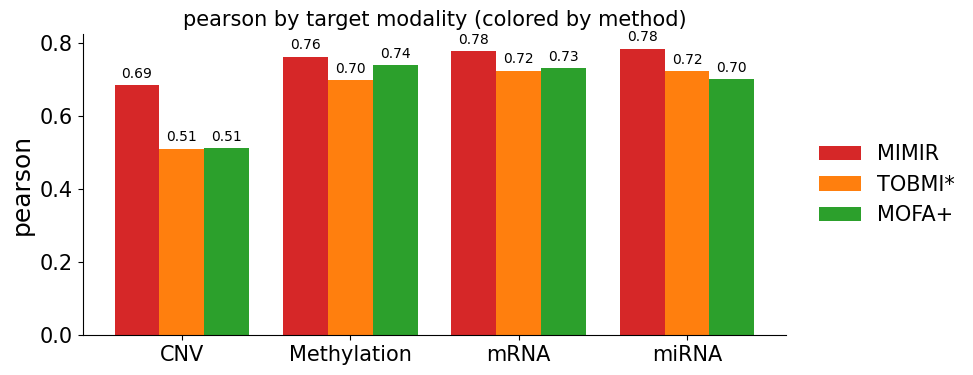

In [61]:
DISPLAY_NAME = {
    "rna": "mRNA",
    "miRNA": "miRNA",
    "cnv": "CNV",
    "methylation": "Methylation",
}
plt.rcParams.update({
    "font.size": 15,
    "axes.labelsize": 18,
    "axes.titlesize": 15,
    "xtick.labelsize": 15,
    "ytick.labelsize": 15,
})

METHOD_COLORS = {
    "MIMIR": "tab:red",
    "TOBMI*": "tab:orange",
    "MOFA+": "tab:green",
}


def metrics_dict_to_df(metrics: dict, method_name: str) -> pd.DataFrame:
    rows = []
    for (present_mods, target), d in metrics.items():
        rows.append({
            "method": method_name,
            "target": target,
            "target_display": DISPLAY_NAME.get(target, target),
            "present_mods": tuple(present_mods),
            "n_present": len(present_mods),
            "mse": d.get("mse"),
            "pearson": d.get("pearson"),
            "spearman": d.get("spearman"),
            "n_points": d.get("n_points"),
        })
    return pd.DataFrame(rows)

df = pd.concat([
    metrics_dict_to_df(mimir_metrics, "MIMIR"),
    metrics_dict_to_df(metrics_tobmi, "TOBMI*"),
    metrics_dict_to_df(mofa_metrics, "MOFA+"),
], ignore_index=True)


metric_key = "pearson"  # or "spearman" or "mse"

df_agg = (
    df.groupby(["method", "target", "target_display"], as_index=False)[metric_key]
      .max()
)


def grouped_barplot(df_agg, metric_key="pearson", method_order=None, target_order=None):
    # Orders
    if method_order is None:
        method_order = list(df_agg["method"].unique())
    if target_order is None:
        target_order = list(df_agg.sort_values("target_display")["target_display"].unique())

    # Pivot to matrix: rows=targets, cols=methods
    mat = (
        df_agg.pivot(index="target_display", columns="method", values=metric_key)
             .reindex(index=target_order, columns=method_order)
    )

    x = np.arange(len(mat.index))
    n_methods = len(mat.columns)
    width = 0.8 / n_methods

    fig, ax = plt.subplots(figsize=(max(10, len(x)*1.3), 4))

    for i, method in enumerate(mat.columns):
        ax.bar(
            x + (i - (n_methods - 1) / 2) * width,
            mat[method].values,
            width=width,
            label=method,
            color=METHOD_COLORS.get(method, None),
        )

    ymax = mat.max().max()
    offset = 0.015 * ymax   # small vertical offset
    
    for i, method in enumerate(mat.columns):
        xs = x + (i - (n_methods - 1) / 2) * width
        ys = mat[method].values
    
        for xi, yi in zip(xs, ys):
            if np.isnan(yi):
                continue
            ax.text(
                xi,
                yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=10,
            )

    ymax = mat.max().max()
    #ax.set_ylim(0, ymax*1.32)

    ax.set_xticks(x)
    ax.set_xticklabels(mat.index, rotation=0)
    ax.set_ylabel(metric_key)
    ax.set_title(f"{metric_key} by target modality (colored by method)")
    ax.legend(
    frameon=False,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5)
)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

grouped_barplot(df_agg, metric_key=metric_key, method_order=["MIMIR","TOBMI*","MOFA+"])


## Summary: fraction of features improved vs baselines

We compute, for each target modality, the fraction of features where MIMIR’s feature-wise correlation exceeds the baseline’s.
This provides a more granular view than global correlation and helps detect cases where improvements are widespread.


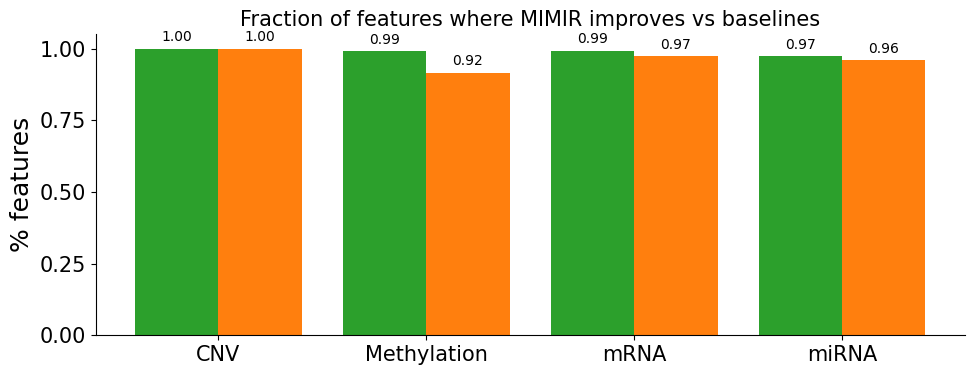

In [67]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DISPLAY_NAME = {
    "rna": "mRNA",
    "miRNA": "miRNA",
    "cnv": "CNV",
    "methylation": "Methylation",
}

def compare_dict_to_df(compare_dict: dict, method_label: str) -> pd.DataFrame:
    rows = []
    for (present_mods, target), d in compare_dict.items():
        rows.append({
            "method": method_label,                # e.g. "vs MOFA+"
            "target": target,
            "target_display": DISPLAY_NAME.get(target, target),
            "frac_better": float(d["n_better_MIMR"]),
            "n_features": int(d.get("n_features", 0)),
            "present_mods": tuple(present_mods),
        })
    return pd.DataFrame(rows)

# Build tidy table
df_cmp = pd.concat([
    compare_dict_to_df(compare_mofa,  "vs MOFA+"),
    compare_dict_to_df(compare_tobmi, "vs TOBMI*"),
], ignore_index=True)

# ---- Grouped bar plot ----
METHOD_COLORS = {
    "vs MOFA+": "tab:orange",
    "vs TOBMI*": "tab:green",
}

def plot_frac_better_grouped(df_cmp, method_order=None, target_order=None):
    if method_order is None:
        method_order = ["vs TOBMI*", "vs MOFA+"]
    if target_order is None:
        # choose your preferred order
        target_order = ["CNV", "Methylation", "mRNA", "miRNA"]

    mat = (
        df_cmp.pivot(index="target_display", columns="method", values="frac_better")
              .reindex(index=target_order, columns=method_order)
    )

    x = np.arange(len(mat.index))
    n_methods = len(mat.columns)
    width = 0.8 / n_methods

    fig, ax = plt.subplots(figsize=(10, 4))

    for i, method in enumerate(mat.columns):
        ax.bar(
            x + (i - (n_methods - 1) / 2) * width,
            mat[method].values,
            width=width,
            label=method,
            color=METHOD_COLORS.get(method, None),
        )

    ymax = mat.max().max()
    offset = 0.015 * ymax   # small vertical offset
    for i, method in enumerate(mat.columns):
        xs = x + (i - (n_methods - 1) / 2) * width
        ys = mat[method].values
    
        for xi, yi in zip(xs, ys):
            if np.isnan(yi):
                continue
            ax.text(
                xi,
                yi + offset,
                f"{yi:.2f}",
                ha="center",
                va="bottom",
                fontsize=10,
            )

    #ax.set_ylim(0, 1.25)
    ax.set_yticks([0.0, 0.25, 0.5, 0.75, 1.0])
    ax.set_xticks(x)
    ax.set_xticklabels(mat.index)
    ax.set_ylabel("% features")
    ax.set_title("Fraction of features where MIMIR improves vs baselines")
    #ax.set_ylim(0, 1.05)

    #ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0.02, 0.98))
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    plt.tight_layout()
    plt.show()

plot_frac_better_grouped(df_cmp)
